**PROJECT: E-COMMERCE PURCHASE PREDICTION**

The project targets the prediction of the purchase intention of a user in an online browsing session. It is created as a supervised binary classification problem, in which the target variable will_purchase will show purchase or no purchase. Based on behavioral and session-level data, a complete machine learning pipeline was trained, that is, preprocessing, feature engineering, model training, cross-validation, and hyperparameter tuning. Numerous models were tested, and the most efficient model was chosen according to ROC-AUC in order to guarantee high level of predictive power and generalization.

In [1]:

# PROJECT: E-COMMERCE PURCHASE PREDICTION


# Objective:
# Predict whether a user will make a purchase based on session behavior.


# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve


import os

os.makedirs("images", exist_ok=True)





In [2]:

# 2. LOAD DATA

df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/2026/ecommerce_purchase.csv')

print("Shape:", df.shape)
print(df.head())


Shape: (10000, 27)
    session_start_time  hour  day_of_week  month  is_weekend  \
0  2024-02-02 07:39:08     7            4      2           0   
1  2024-12-12 15:37:55    15            3     12           0   
2  2024-02-24 19:33:54    19            5      2           1   
3  2024-09-26 12:46:30    12            3      9           0   
4  2024-11-03 18:30:12    18            6     11           1   

   session_duration_minutes  days_since_last_visit  page_views    clicks  \
0                  4.241725               3.033577    0.962865  0.000000   
1                  5.000125               7.316292    0.996749  0.000000   
2                 10.552687               0.432975    1.984853  1.012054   
3                 18.705162               3.612518    2.980036  1.027641   
4                  6.360490               9.746390    1.077701  0.000000   

   avg_scroll_depth  ...  traffic_source    customer_segment  \
0          0.182760  ...  organic_search  returning_customer   
1          

In [3]:

# 3. BASIC CHECKS

print(df.info())
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   session_start_time         10000 non-null  object 
 1   hour                       10000 non-null  int64  
 2   day_of_week                10000 non-null  int64  
 3   month                      10000 non-null  int64  
 4   is_weekend                 10000 non-null  int64  
 5   session_duration_minutes   10000 non-null  float64
 6   days_since_last_visit      9500 non-null   float64
 7   page_views                 10000 non-null  float64
 8   clicks                     10000 non-null  float64
 9   avg_scroll_depth           10000 non-null  float64
 10  items_added_to_cart        10000 non-null  int64  
 11  items_removed_from_cart    10000 non-null  int64  
 12  search_queries_count       10000 non-null  int64  
 13  product_page_time_minutes  10000 non-null  floa

In [4]:

# 4. FEATURE ENGINEERING (NEW - ADVANCED)

df['session_start_time'] = pd.to_datetime(df['session_start_time'])
df['hour'] = df['session_start_time'].dt.hour

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Drop unnecessary columns
df = df.drop(columns=['session_start_time','search_queries','categories_viewed','user_agent'])

print("Feature Engineering Done")


Feature Engineering Done


This plot shows the distribution of users who made a purchase versus those who did not. The dataset is relatively balanced, with a slightly higher number of purchases, which is beneficial for training a classification model without bias toward one class.

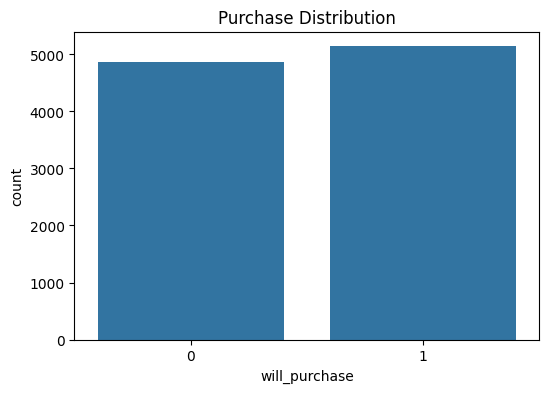

In [5]:

# 5. EDA

plt.figure(figsize=(6,4))
sns.countplot(x='will_purchase', data=df)
plt.title("Purchase Distribution")
plt.savefig("images/purchase_distribution.png", bbox_inches="tight")
plt.show()
plt.close()



This boxplot compares session duration for purchasers and non-purchasers. Users who make a purchase generally have higher session durations, indicating that increased time spent on the website is associated with higher purchase intent.

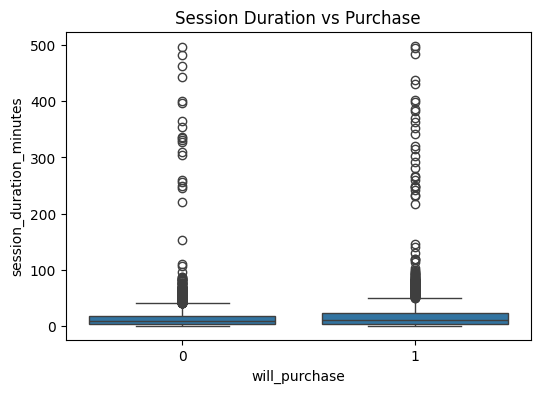

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x='will_purchase', y='session_duration_minutes', data=df)
plt.title("Session Duration vs Purchase")
plt.savefig("images/session_duration.png", bbox_inches="tight")
plt.show()
plt.close()


This plot shows that users who add more items to their cart are more likely to complete a purchase. Although there are some outliers, the overall trend indicates that cart activity is a strong indicator of buying intent.

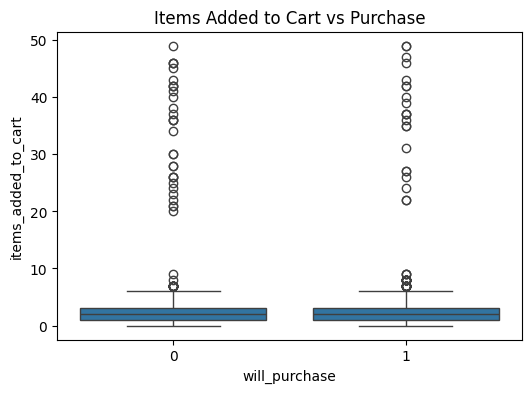

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x='will_purchase', y='items_added_to_cart', data=df)
plt.title("Items Added to Cart vs Purchase")
plt.savefig("images/cart_items.png", bbox_inches="tight")
plt.show()
plt.close()


This histogram shows that most users have low page views, but users with higher page views are more likely to make a purchase. This suggests that higher engagement increases the likelihood of conversion.

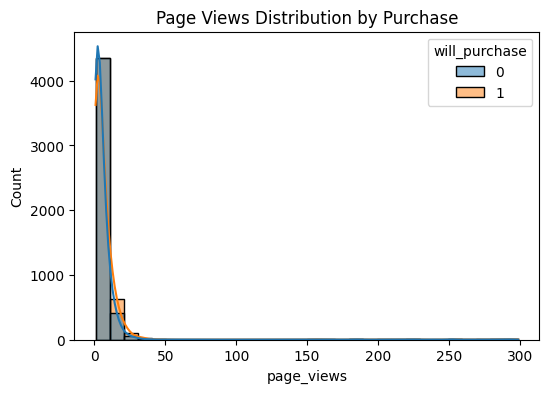

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='page_views', hue='will_purchase', bins=30, kde=True)
plt.title("Page Views Distribution by Purchase")
plt.savefig("images/page_views.png", bbox_inches="tight")
plt.show()
plt.close()

This chart shows conversion rates across different traffic sources. Email and paid search have higher conversion rates, indicating they bring more high-intent users, while social media has a comparatively lower conversion rate.

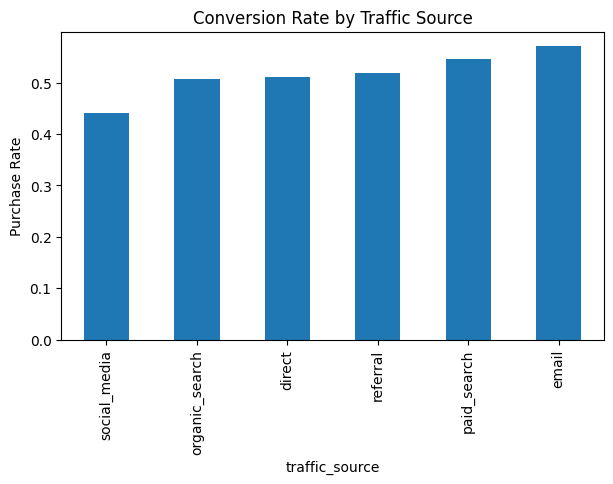

In [9]:
conversion = df.groupby('traffic_source')['will_purchase'].mean().sort_values()

plt.figure(figsize=(7,4))
conversion.plot(kind='bar')
plt.title("Conversion Rate by Traffic Source")
plt.ylabel("Purchase Rate")
plt.savefig("images/traffic_source.png", bbox_inches="tight")
plt.show()
plt.close()

This plot shows how purchase probability varies across different hours of the day. There are noticeable fluctuations, suggesting that user purchasing behavior depends on time, with certain hours showing higher conversion rates.

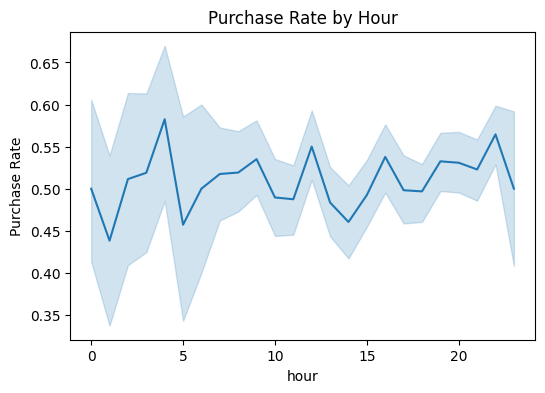

In [10]:
plt.figure(figsize=(6,4))
sns.lineplot(x='hour', y='will_purchase', data=df, estimator='mean')
plt.title("Purchase Rate by Hour")
plt.ylabel("Purchase Rate")
plt.savefig("images/hour_purchase.png", bbox_inches="tight")
plt.show()
plt.close()

**Analysis of Data Characteristics**

Exploratory data analysis revealed key patterns in customer purchase behavior. The target variable (will_purchase) is relatively balanced, ensuring unbiased model evaluation using metrics like ROC-AUC.

Customer engagement features showed strong relationships with purchasing. Longer session durations, higher page views, and more items added to cart were associated with a higher likelihood of purchase.

Traffic source analysis indicated that conversion rates vary across channels, suggesting differences in the quality of users from each source. Temporal patterns also showed that purchase likelihood changes across different hours of the day, supporting the use of time-based features.

Overall, customer engagement, traffic source, and time-related features are important drivers of purchase behavior and guided feature engineering and model selection.

FEATURE ENGINEERING

 Here we will separate the dataset into input features (X) and the target variable (y) with will purchase being the variable we will be predicting. Then the feature set is further divided into numerical and categorical columns according to their type of data. The difference is significant in that preprocessing methods of each type vary (i.e. numerical features are scaled and categorical features are encoded).

In [11]:

# 6. FEATURE SPLIT

X = df.drop('will_purchase', axis=1)
y = df['will_purchase']

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns


Here, a preprocessing pipeline is developed by means of the ColumnTransformer to process numerical and categorical features independently in an organized and effective manner. In the case of numerical characteristics, the missing cases are filled in with the median imputation, followed by a normalization of the data with the StandardScaler. In the case of categorical features, the most frequent category is used to fill in the missing values, which are then turned into the numerical form (with OneHotEncoder) with the unknown categories being treated safely. This pipeline will make all the preprocessing processes uniform in training and testing, enhancing model reliability and avoiding data leakage.

In [12]:

# 7. PIPELINE (BEST PRACTICE)

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


This step splits the dataset into training and testing sets, where 80% of the data is used to train the model and 20% is used to evaluate its performance. The random_state=42 ensures reproducibility, and stratify=y maintains the same class distribution in both sets to avoid bias.

In [13]:

# 8. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




The code builds a Logistic Regression model using a pipeline that includes preprocessing and model training. The model is trained on the training dataset and used to predict purchase outcomes on the test set. Performance is evaluated using ROC-AUC and classification metrics. Logistic Regression serves as a baseline model to compare against more complex models.

In [14]:

# 9. MODEL 1: LOGISTIC REGRESSION

log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

log_roc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])

print("Logistic Regression ROC:", log_roc)
print(classification_report(y_test, log_preds))
print("Insight: Baseline linear model.")



Logistic Regression ROC: 0.6102504363420922
              precision    recall  f1-score   support

           0       0.57      0.54      0.56       972
           1       0.59      0.62      0.60      1028

    accuracy                           0.58      2000
   macro avg       0.58      0.58      0.58      2000
weighted avg       0.58      0.58      0.58      2000

Insight: Baseline linear model.


The Random Forest model is trained using a pipeline with preprocessing and evaluated using ROC-AUC and classification metrics. It captures complex, non-linear relationships in the data and improves prediction performance. Class balancing is applied to handle uneven class distribution

In [15]:

# 10. MODEL 2: RANDOM FOREST

rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("Random Forest ROC:", rf_roc)
print(classification_report(y_test, rf_preds))
print("Insight: Captures complex patterns.")



Random Forest ROC: 0.608005676450337
              precision    recall  f1-score   support

           0       0.57      0.54      0.56       972
           1       0.59      0.62      0.60      1028

    accuracy                           0.58      2000
   macro avg       0.58      0.58      0.58      2000
weighted avg       0.58      0.58      0.58      2000

Insight: Captures complex patterns.


The Gradient Boosting model is trained using a preprocessing pipeline and evaluated using ROC-AUC and classification metrics. It improves performance by sequentially learning from errors and capturing complex patterns.

In [16]:

# 11. MODEL 3: GRADIENT BOOSTING (NEW)

gb_model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])

print("Gradient Boosting ROC:", gb_roc)
print(classification_report(y_test, gb_preds))

Gradient Boosting ROC: 0.6325519207058334
              precision    recall  f1-score   support

           0       0.59      0.53      0.56       972
           1       0.59      0.65      0.62      1028

    accuracy                           0.59      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.59      0.59      0.59      2000




Model Comparison Insight:
Gradient Boosting achieved the highest ROC-AUC in both test and cross-validation,
making it the best performing model.

This indicates it captures complex patterns effectively.

This code performs 5-fold cross-validation on Logistic Regression, Random Forest, and Gradient Boosting models using ROC-AUC as the evaluation metric. It splits the data into 5 parts, trains the model on different subsets, and calculates the average ROC-AUC score to measure how well each model generalizes.

In [17]:

# CROSS VALIDATION FOR ALL MODELS

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {scores.mean():.3f}")


Logistic Regression CV ROC-AUC: 0.607
Random Forest CV ROC-AUC: 0.598
Gradient Boosting CV ROC-AUC: 0.619


This code performs hyperparameter tuning on the Gradient Boosting model using GridSearchCV. It tests different parameter combinations (number of trees, learning rate, and tree depth) using 3-fold cross-validation and selects the best model based on ROC-AUC score. The optimal model is stored as best_model.

In [18]:

# 13. HYPERPARAMETER TUNING (GRADIENT BOOSTING)


gb_param_grid = {
    'model__n_estimators': [50, 100, 150],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(gb_model, gb_param_grid, cv=3, scoring='roc_auc')
gb_grid.fit(X_train, y_train)



best_model = gb_grid.best_estimator_

print("Best Parameters:", gb_grid.best_params_)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 150}


This code uses the tuned Gradient Boosting model to make final predictions and calculate purchase probabilities on the test data. It evaluates the model using ROC-AUC and classification metrics to measure its performance. This represents the final optimized model used for prediction.

In [19]:


# 14. FINAL MODEL (TUNED GRADIENT BOOSTING)


final_preds = best_model.predict(X_test)
final_probs = best_model.predict_proba(X_test)[:,1]

final_roc = roc_auc_score(y_test, final_probs)

print("Final Tuned Gradient Boosting ROC:", final_roc)
print(classification_report(y_test, final_preds))




Final Tuned Gradient Boosting ROC: 0.6384895758274487
              precision    recall  f1-score   support

           0       0.60      0.54      0.57       972
           1       0.60      0.66      0.63      1028

    accuracy                           0.60      2000
   macro avg       0.60      0.60      0.60      2000
weighted avg       0.60      0.60      0.60      2000



The model achieves a recall of 0.66 for the purchase class, effectively identifying most potential buyers. While the precision of 0.60 indicates some false positives, the model is more effective at capturing buyers than non-buyers, making it valuable for improving conversion rates and targeting high-intent customers.

This code extracts and visualizes the most important features from the tuned Gradient Boosting model. It ranks features based on their impact on predictions and displays the top contributors using a bar chart. This helps identify the key drivers influencing customer purchase behavior.

Confusion Matrix:
 [[524 448]
 [352 676]]


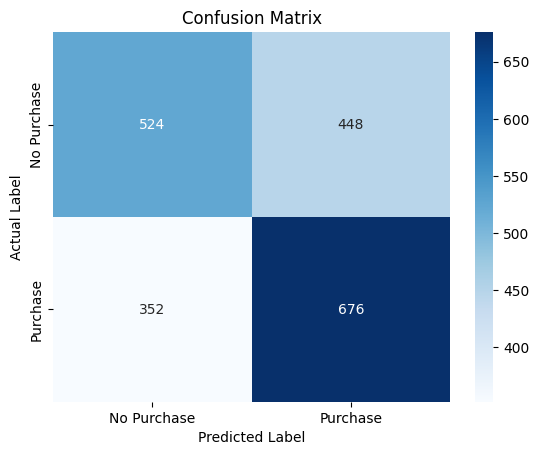

<Figure size 640x480 with 0 Axes>

In [25]:
# Predictions from best model
final_preds = best_model.predict(X_test)


cm = confusion_matrix(y_test, final_preds)


print("Confusion Matrix:\n", cm)


plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


plt.savefig("confusion_matrix.png")

Train Confusion Matrix:
 [[2108 1779]
 [1290 2823]]


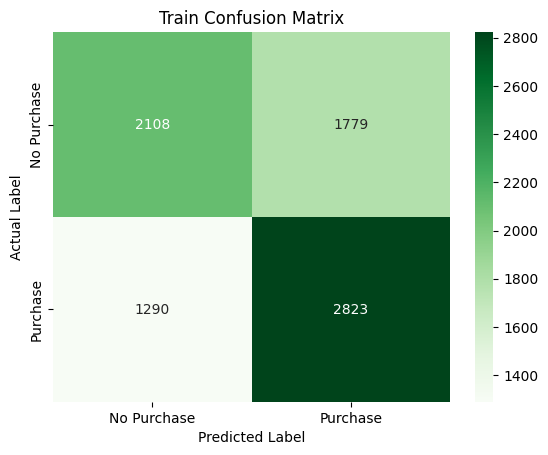

In [27]:
from sklearn.metrics import confusion_matrix

# Predictions on TRAIN data
train_preds = best_model.predict(X_train)

# Confusion matrix on TRAIN data
cm_train = confusion_matrix(y_train, train_preds)

print("Train Confusion Matrix:\n", cm_train)
plt.figure()
sns.heatmap(cm_train,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Train Confusion Matrix")

plt.show()

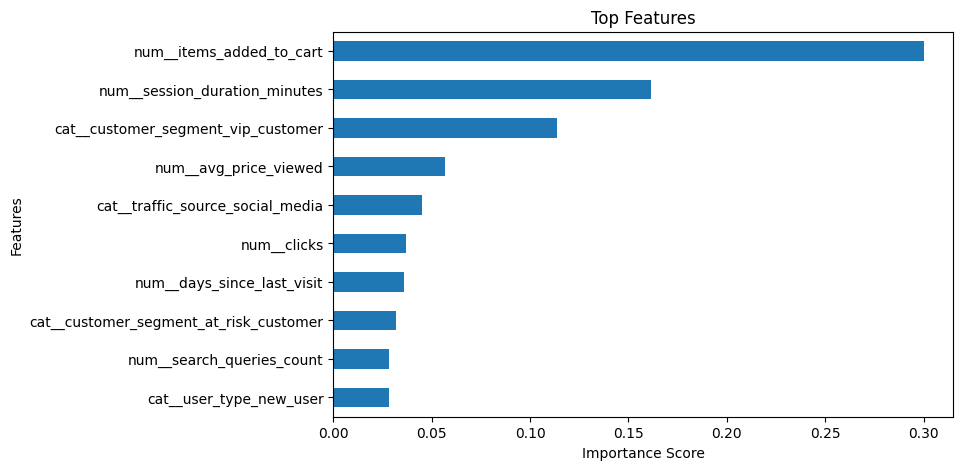

Insight: Identifies key drivers of purchase.


In [24]:

# 16. FEATURE IMPORTANCE



importances = best_model.named_steps['model'].feature_importances_
feature_names = best_model.named_steps['prep'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)


plt.figure(figsize=(8,5))

# Plot top 10 features
feat_imp.head(10).plot(kind='barh')

plt.title("Top Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Invert so most important is on top
plt.gca().invert_yaxis()


plt.savefig("images/feature_importance.png", bbox_inches='tight')

plt.show()
plt.close()

print("Insight: Identifies key drivers of purchase.")


The most important feature is the number of items added to the cart, followed by time spent on the site, showing that more active users have a higher chance of making a purchase. This helps businesses identify high-intent customers and target them with personalized offers to improve conversion rates

This code plots the ROC curve using the model’s predicted probabilities. It shows the trade-off between true positive rate and false positive rate, helping evaluate how well the model distinguishes between purchase and non-purchase cases.

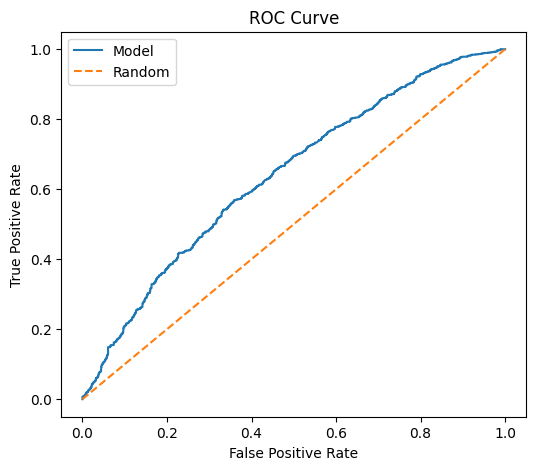

In [22]:

# 17. ROC CURVE



# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test, final_probs)

# Create fresh figure
plt.figure(figsize=(6,5))

# Plot ROC curve
plt.plot(fpr, tpr, label="Model")
plt.plot([0,1], [0,1], linestyle='--', label="Random")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()


plt.savefig("images/roc_curve.png", bbox_inches='tight')

plt.show()
plt.close()


Conclusion:

Gradient Boosting performed best based on both test and cross-validation ROC-AUC scores.

Hyperparameter tuning further improved its performance.

Key drivers include:
- Session duration
- Items added to cart
- Page views
- Clicks
- Time spent

This model can help improve conversion rates and targeting.

Using the predicted probabilities from the model, Company A Solutions can identify customers who are likely to make a purchase (1) and those who are unlikely (0). By applying a threshold (e.g., 0.5), customers with higher probabilities can be targeted with personalized offers, recommendations, or promotions in real time. This enables businesses to optimize marketing spend, focus on high-intent users, and improve overall conversion rates.

In [23]:
best_model = gb_grid.best_estimator_

purchase_probs = best_model.predict_proba(X_test)[:, 1]
print(purchase_probs[:10])

[0.61692276 0.45043503 0.46737868 0.66701959 0.4492427  0.55183356
 0.45409244 0.34909844 0.48958804 0.57293155]


Customers were ranked based on their predicted purchase probability. High-probability customers (above 0.6) were identified as potential buyers and prioritized for targeted marketing strategies. These customers typically show higher engagement through longer session durations, more page views, and recent activity. This segmentation enables the business team to optimize marketing spend by focusing on users most likely to convert.